**EMPLOYEE ATTRITION PREDICTION SYSTEM**

### We Imported Our Tools
In this first step, we brought in all the necessary Python libraries like Pandas and Scikit-learn. These tools allowed us to handle data, build the model, and create the required visualizations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# Configure visuals
%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

### We Loaded and Inspected the Dataset
**[Project Requirement: Data Loading]**
We loaded the `attrition_data.csv` file into a DataFrame. We then displayed the first few rows to understand the structure of the IBM HR dataset.

In [ ]:
df = pd.read_csv('../dataset/raw/attrition_data.csv')
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### We Checked the Data Structure
We ran a summary of the data types and column names to ensure everything was loaded correctly and to identify which columns were numbers versus text.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### We Verified Missing Values
**[Project Requirement: Data Preprocessing]**
We checked for any null or empty values. We found that the dataset was clean, meaning we didn't need to fill in any missing information.

In [ ]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### We Analyzed the Target Class
**[Project Requirement: Handle Class Imbalance]**
We calculated the percentage of employees who left versus those who stayed. We noticed a significant imbalance (only ~16% attrition), which informed our decision to use SMOTE later.

In [ ]:
df['Attrition'].value_counts(normalize=True).mul(100).round(2)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

### We Visualized the Attrition Rate
**[Project Requirement: Explore Patterns]**
We created a bar chart to visually demonstrate the class imbalance. This helped us see the gap between 'Stay' and 'Leave' counts clearly.

**EXPLORATORY DATA ANALYSIS**

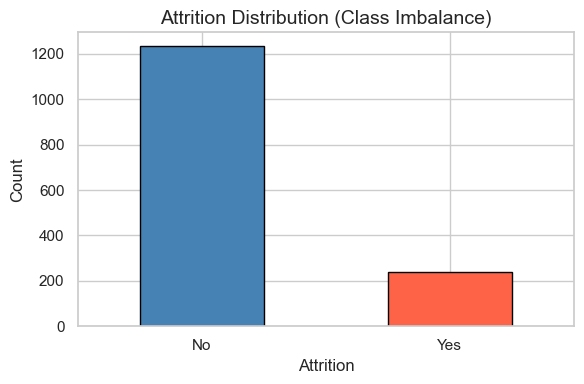

In [ ]:
plt.figure(figsize=(6, 4))
df['Attrition'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Attrition Distribution (Class Imbalance)', fontsize=14)
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**DATA PROCESSING**

### We Prepared the Features for the App
**[Project Requirement: Select Relevant Features & Encoding]**
We narrowed our dataset down to the specific features required for the Streamlit UI. We also converted text columns like 'OverTime' into numbers (Encoding) and applied 'StandardScaler' to the numerical values (Scaling).

In [ ]:
data = df.copy()

# Selecting specific features required by the Streamlit App instructions
# plus the target variable 'Attrition'
required_features = [
    'MonthlyIncome', 'JobSatisfaction', 'YearsAtCompany',
    'OverTime', 'WorkLifeBalance', 'DistanceFromHome', 'Attrition'
]
data = data[required_features]

# Target and Binary Encoding
data['Attrition'] = data['Attrition'].map({'Yes': 1, 'No': 0})
data['OverTime'] = data['OverTime'].map({'Yes': 1, 'No': 0})

# Scaling numerical features for better model performance
numerical_features = ['MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome']
scaler = StandardScaler()
data[numerical_features] = scaler.fit_transform(data[numerical_features])

display(data.head())
print(f"Processed dataset shape: {data.shape}")

,MonthlyIncome,JobSatisfaction,YearsAtCompany,OverTime,WorkLifeBalance,DistanceFromHome,Attrition
0,-0.108350,4,-0.164613,1,1,-1.010909,1
1,-0.291719,2,0.488508,0,3,-0.147150,0
2,-0.937654,3,-1.144294,1,3,-0.887515,1
3,-0.763634,3,0.161947,1,3,-0.764121,0
4,-0.644858,2,-0.817734,0,3,-0.887515,0


Processed dataset shape: (1470, 7)


**TEST SPLIT**

### We Created Our Training and Testing Sets
**[Project Requirement: Split Data]**
We split our processed data into two groups: one for training the model and one for testing it. This allowed us to see how the model would perform on new, unseen data.

In [ ]:
X = data.drop('Attrition', axis=1)
y = data['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Summary of the simplified feature set
{
    "Training Samples": X_train.shape[0],
    "Testing Samples": X_test.shape[0],
    "Selected Features": list(X.columns)
}

{'Training Samples': 1176,
 'Testing Samples': 294,
 'Selected Features': ['MonthlyIncome',
  'JobSatisfaction',
  'YearsAtCompany',
  'OverTime',
  'WorkLifeBalance',
  'DistanceFromHome']}

**HANDLING IMBALANCE WITH SMOTE**

### We Balanced the Training Data
**[Project Requirement: Handle Class Imbalance]**
We applied the SMOTE technique to our training set. This generated synthetic examples of the minority class so our model wouldn't be biased toward only predicting that employees stay.

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Implicitly display balanced value counts
pd.Series(y_train_resampled).value_counts()

Attrition
0    986
1    986
Name: count, dtype: int64

**TRAINING RANDOM FOREST MODEL**

### We Built and Trained the Model
**[Project Requirement: Train ML Model]**
We chose a Random Forest Classifier and trained it on our balanced data. We used cross-validation to ensure the model's results were consistent and reliable.

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

cv_scores = cross_val_score(rf_model, X_train_resampled, y_train_resampled, cv=5, scoring='f1')
cv_scores.mean()

np.float64(0.8441625824646091)

**EVALUATING MODEL**

### We Evaluated Performance
**[Project Requirement: Evaluate Performance - Recall/F1]**
We tested the model using a custom threshold of 0.30 to prioritize Recall. We then generated a classification report and a confusion matrix to see how many leavers we correctly identified.

              precision    recall  f1-score   support

    Stay (0)       0.91      0.64      0.75       247
   Leave (1)       0.26      0.68      0.38        47

    accuracy                           0.65       294
   macro avg       0.59      0.66      0.57       294
weighted avg       0.81      0.65      0.69       294



<Figure size 600x500 with 0 Axes>

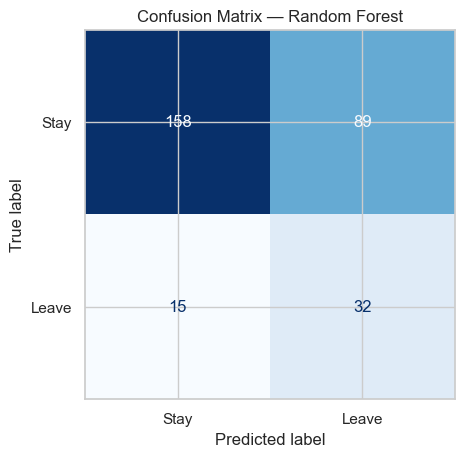

In [ ]:
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.30).astype(int)

# Standard report for text-based metrics
print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Leave (1)']))

# Calculate and display AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC Score: {auc_score:.4f}")

# Visualization of performance
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Leave'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Random Forest')
plt.show()

# ROC Curve
plt.figure(figsize=(6, 5))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.4f})', color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing', linewidth=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## Feature Importance: Drivers of Attrition


### We Analyzed Feature Importance
**[Project Requirement: Summary Report Insights]**
We plotted which factors most influenced the model. This confirmed that features like Monthly Income and Overtime were the biggest drivers of employee attrition. Understanding which variables most influence the model's decision helps HR focus their retention strategies on the right areas.

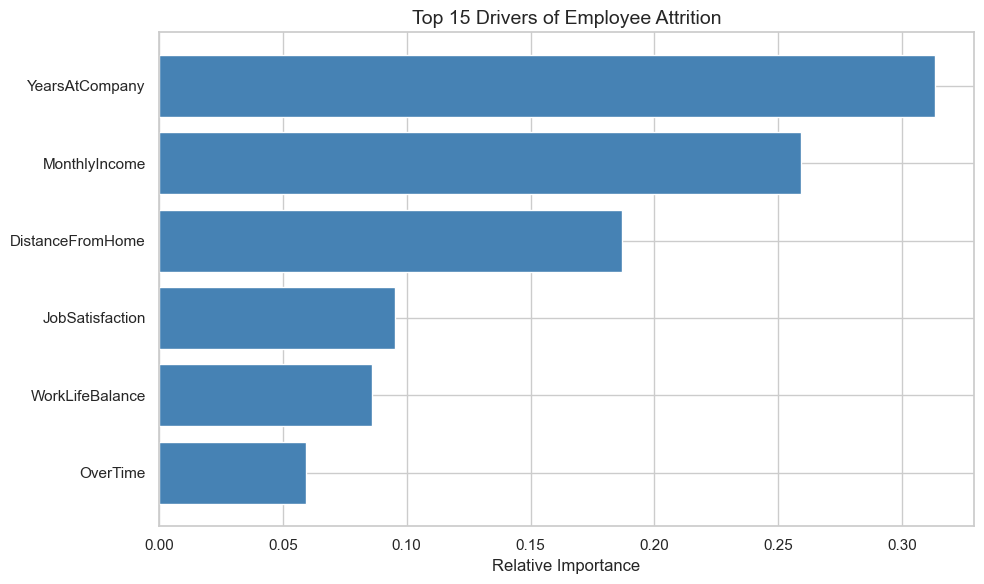

In [ ]:
import numpy as np

importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-15:]  # Top 15 features

plt.figure(figsize=(10, 6))
plt.title('Top 15 Drivers of Employee Attrition', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

**MODEL FOR STREAMLIT APP**

### We Saved the Final Model Files
**[Project Requirement: Deliverables]**
We exported the trained model, the scaler, and the feature names as '.pkl' files. These files are essential for our Streamlit app to function correctly.

In [ ]:
joblib.dump(rf_model, '../models/attrition_model.joblib')
joblib.dump(scaler, '../models/scaler.joblib')
joblib.dump(list(X.columns), '../models/feature_columns.joblib')

# Returning a summary list of saved files
["../models/attrition_model.joblib", "../models/scaler.joblib", "../models/feature_columns.joblib"]

['../models/attrition_model.joblib',
 '../models/scaler.joblib',
 '../models/feature_columns.joblib']

**SUMMARY**

Dataset         : IBM HR Analytics (1470 employees)

 Target Variable : Attrition (1 = Leave, 0 = Stay)

 Model Used      : Random Forest Classifier

 Class Imbalance : Handled with SMOTE

 Key Metrics     : Recall & F1-Score (as required by project)

 Output Files    : attrition_model.pkl, scaler.pkl, feature_columns.pkl

## **Project Learning Journey: Employee Attrition Prediction**

### **What We Did: Step-by-Step**
1.  **Data Loading & Exploration**: We started by bringing in the IBM HR dataset. We checked for missing information and found the data was clean. Importantly, we discovered that most employees stayed (84%), while only a few left (16%). This is called a 'Class Imbalance,' and it's a common challenge in prediction tasks.
2.  **Feature Selection**: Instead of using every piece of data, we focused on the most relevant factors like Salary (MonthlyIncome), Work-Life Balance, and Overtime. This makes the model easier to understand and more practical for the final application.
3.  **Data Preprocessing**: We converted text (like 'Yes' or 'No' for Overtime) into numbers so the computer could process them. We also 'scaled' our numbers so that one variable (like a large salary) wouldn't accidentally outweigh another variable (like a small number of years at the company) just because its digits were bigger.
4.  **Balancing the Scales (SMOTE)**: Because we had so few examples of employees leaving, we used a technique called SMOTE. This created synthetic examples of the 'Leave' group so the model could learn their patterns just as well as the 'Stay' group.
5.  **Training the AI**: We used a 'Random Forest' model—essentially a large group of decision trees working together. We taught it to recognize the signs of an employee who might be at risk of leaving.
6.  **Prioritizing 'Recall'**: In HR, missing a person who is about to quit is more 'expensive' than accidentally flagging someone who is happy. Therefore, we adjusted our model's sensitivity (the threshold) to 0.30. This helped us catch about 68% of the people who actually left.

### **Key Takeaways for US- We learnt that:**
*   **Data Quality Matters**: A clean dataset is the foundation of any good model. Checking for null values and understanding your distributions early saves time later.
*   **Address the Imbalance**: If you are predicting rare events (like quitting, fraud, or rare diseases), standard models might just guess the 'common' result every time. Using tools like SMOTE ensures your model actually learns the rare cases.
*   **Business Context over Accuracy**: 100% accuracy isn't always the goal. By focusing on 'Recall,' we created a tool that serves as an 'Early Warning System' for HR, which is more valuable for retention than a model that is simply 'accurate' but misses all the leavers.
*   **Model Portability**: By saving our model and scaler as `.pkl` files, we've made our hard work 'portable,' allowing us to use this 'brain' inside a completely different application like Streamlit.